In [1]:
# imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pymongo import MongoClient
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from dotenv import load_dotenv
import os

### 1. Pulling Data from MongoDB

In [2]:
load_dotenv()
client = MongoClient(os.getenv("MONGO_URI"))
collection = client["data_by_design"]["election_economics"]

df = pd.DataFrame(list(collection.find({}, {"_id": 0})))
df = df.dropna(subset=["gas_price_change_pct", "inflation_rate"])  # drop 2020
print(f"Loaded {len(df)} documents across {df['year'].nunique()} election years")

Loaded 561 documents across 11 election years


### 2. Aggregating to national level

In [3]:
national = df.groupby(["year", "incumbent_party", "gas_price_change_pct", "inflation_rate"]) \
             .agg(avg_vote_share=("incumbent_vote_share", "mean")) \
             .reset_index() \
             .sort_values("year")

print("\nNational-level summary:")
print(national.to_string(index=False))


National-level summary:
 year incumbent_party  gas_price_change_pct  inflation_rate  avg_vote_share
 1980        DEMOCRAT                 37.85           13.50       39.910980
 1984      REPUBLICAN                 -2.33            4.37       59.707059
 1988      REPUBLICAN                 -0.24            4.10       53.662745
 1992      REPUBLICAN                 -1.19            3.04       37.555098
 1996        DEMOCRAT                  7.30            2.94       47.909608
 2000        DEMOCRAT                 29.60            3.37       45.919020
 2004      REPUBLICAN                 18.19            2.67       52.219804
 2008      REPUBLICAN                 16.63            3.81       46.946078
 2012        DEMOCRAT                  3.33            2.07       48.941569
 2016        DEMOCRAT                -12.50            1.27       44.568627
 2020      REPUBLICAN                -17.52            1.25       49.157059


### 3. Correlation matrix

In [7]:
print("\nCorrelation Matrix ")
corr = national[["avg_vote_share", "gas_price_change_pct", "inflation_rate"]].corr()
print(corr.round(3))


Correlation Matrix 
                      avg_vote_share  gas_price_change_pct  inflation_rate
avg_vote_share                 1.000                -0.276          -0.298
gas_price_change_pct          -0.276                 1.000           0.689
inflation_rate                -0.298                 0.689           1.000


### 4. Regression: Vote Share &  Gas Price Change

In [8]:
print("\nRegression: Vote Share ~ Gas Price Change")
X_gas = national[["gas_price_change_pct"]].values
y = national["avg_vote_share"].values

model_gas = LinearRegression().fit(X_gas, y)
y_pred_gas = model_gas.predict(X_gas)
r2_gas = r2_score(y, y_pred_gas)

print(f"Coefficient : {model_gas.coef_[0]:.4f}")
print(f"Intercept   : {model_gas.intercept_:.4f}")
print(f"R²          : {r2_gas:.4f}")
print(f"Interpretation: A 1% increase in gas prices is associated with a "
      f"{model_gas.coef_[0]:.3f}% change in incumbent vote share")


Regression: Vote Share ~ Gas Price Change
Coefficient : -0.1002
Intercept   : 48.5844
R²          : 0.0760
Interpretation: A 1% increase in gas prices is associated with a -0.100% change in incumbent vote share


### 5. Regression: Vote Share & Inflation Rate

In [9]:
print("\nRegression: Vote Share ~ Inflation Rate")
X_inf = national[["inflation_rate"]].values

model_inf = LinearRegression().fit(X_inf, y)
y_pred_inf = model_inf.predict(X_inf)
r2_inf = r2_score(y, y_pred_inf)

print(f"Coefficient : {model_inf.coef_[0]:.4f}")
print(f"Intercept   : {model_inf.intercept_:.4f}")
print(f"R²          : {r2_inf:.4f}")
print(f"Interpretation: A 1% increase in inflation is associated with a "
      f"{model_inf.coef_[0]:.3f}% change in incumbent vote share")



Regression: Vote Share ~ Inflation Rate
Coefficient : -0.5460
Intercept   : 49.9674
R²          : 0.0886
Interpretation: A 1% increase in inflation is associated with a -0.546% change in incumbent vote share


### 6. Multiple Regression: Vote Share ~ Gas + Inflation 

In [10]:
print("\nMultiple Regression: Vote Share ~ Gas + Inflation")
X_multi = national[["gas_price_change_pct", "inflation_rate"]].values

model_multi = LinearRegression().fit(X_multi, y)
y_pred_multi = model_multi.predict(X_multi)
r2_multi = r2_score(y, y_pred_multi)

print(f"Gas coefficient       : {model_multi.coef_[0]:.4f}")
print(f"Inflation coefficient : {model_multi.coef_[1]:.4f}")
print(f"Intercept             : {model_multi.intercept_:.4f}")
print(f"R²                    : {r2_multi:.4f}")


Multiple Regression: Vote Share ~ Gas + Inflation
Gas coefficient       : -0.0489
Inflation coefficient : -0.3759
Intercept             : 49.6638
R²                    : 0.0981


### 7. Visualizations

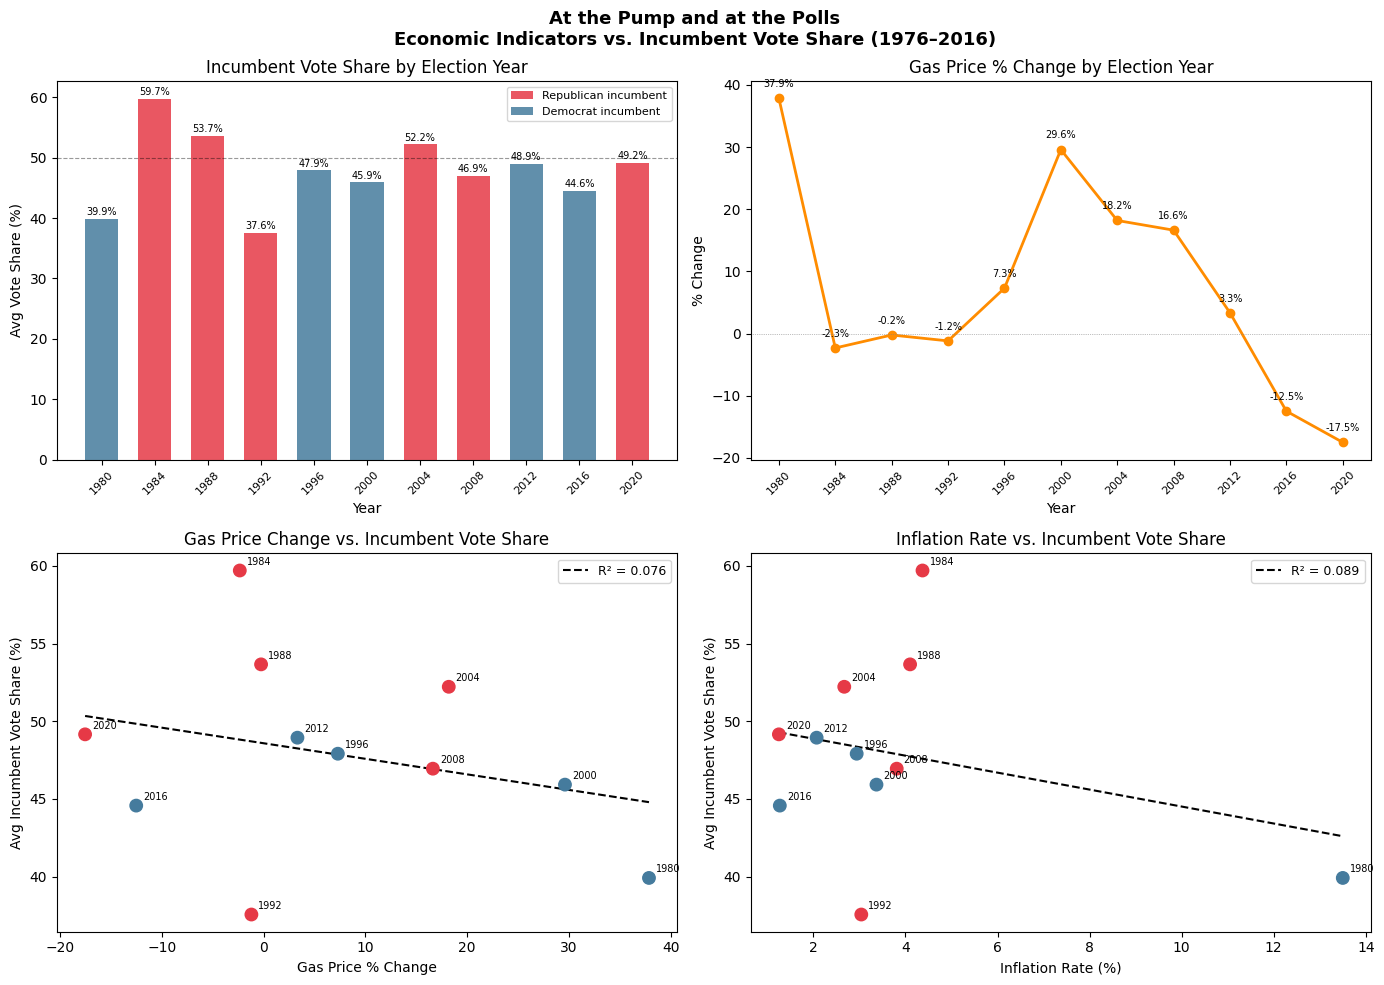

Chart saved to economic_voting_analysis.png

 Model Comparison 
          Model    R²
 Gas Price Only 0.076
 Inflation Only 0.089
Gas + Inflation 0.098


In [11]:
colors = ["#E63946" if p == "REPUBLICAN" else "#457B9D"
          for p in national["incumbent_party"]]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("At the Pump and at the Polls\nEconomic Indicators vs. Incumbent Vote Share (1976–2016)",
             fontsize=13, fontweight="bold")

# Plot 1: Vote share over time 
ax1 = axes[0, 0]
bars = ax1.bar(national["year"], national["avg_vote_share"],
               color=colors, width=2.5, alpha=0.85)
ax1.axhline(50, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax1.set_title("Incumbent Vote Share by Election Year")
ax1.set_xlabel("Year")
ax1.set_ylabel("Avg Vote Share (%)")
ax1.set_xticks(national["year"])
ax1.set_xticklabels(national["year"], rotation=45, fontsize=8)
for bar, val in zip(bars, national["avg_vote_share"]):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=7)
legend_elements = [
    Patch(facecolor="#E63946", alpha=0.85, label="Republican incumbent"),
    Patch(facecolor="#457B9D", alpha=0.85, label="Democrat incumbent")
]
ax1.legend(handles=legend_elements, fontsize=8)

# Plot 2: Gas price change over time 
ax2 = axes[0, 1]
ax2.plot(national["year"], national["gas_price_change_pct"],
         color="darkorange", marker="o", linewidth=2, markersize=6)
ax2.axhline(0, color="grey", linewidth=0.5, linestyle=":")
ax2.set_title("Gas Price % Change by Election Year")
ax2.set_xlabel("Year")
ax2.set_ylabel("% Change")
ax2.set_xticks(national["year"])
ax2.set_xticklabels(national["year"], rotation=45, fontsize=8)
for x, y_val in zip(national["year"], national["gas_price_change_pct"]):
    ax2.annotate(f"{y_val:.1f}%", (x, y_val),
                 textcoords="offset points", xytext=(0, 8),
                 ha="center", fontsize=7)

# Plot 3: Scatter — gas price vs vote share with regression line 
ax3 = axes[1, 0]
ax3.scatter(national["gas_price_change_pct"], national["avg_vote_share"],
            color=colors, s=80, zorder=3)
x_range = np.linspace(national["gas_price_change_pct"].min(),
                      national["gas_price_change_pct"].max(), 100).reshape(-1, 1)
ax3.plot(x_range, model_gas.predict(x_range),
         color="black", linewidth=1.5, linestyle="--", label=f"R² = {r2_gas:.3f}")
for _, row in national.iterrows():
    ax3.annotate(str(int(row["year"])),
                 (row["gas_price_change_pct"], row["avg_vote_share"]),
                 textcoords="offset points", xytext=(5, 4), fontsize=7)
ax3.set_title("Gas Price Change vs. Incumbent Vote Share")
ax3.set_xlabel("Gas Price % Change")
ax3.set_ylabel("Avg Incumbent Vote Share (%)")
ax3.legend(fontsize=9)

# Plot 4: Scatter — inflation vs vote share with regression line 
ax4 = axes[1, 1]
ax4.scatter(national["inflation_rate"], national["avg_vote_share"],
            color=colors, s=80, zorder=3)
x_range_inf = np.linspace(national["inflation_rate"].min(),
                           national["inflation_rate"].max(), 100).reshape(-1, 1)
ax4.plot(x_range_inf, model_inf.predict(x_range_inf),
         color="black", linewidth=1.5, linestyle="--", label=f"R² = {r2_inf:.3f}")
for _, row in national.iterrows():
    ax4.annotate(str(int(row["year"])),
                 (row["inflation_rate"], row["avg_vote_share"]),
                 textcoords="offset points", xytext=(5, 4), fontsize=7)
ax4.set_title("Inflation Rate vs. Incumbent Vote Share")
ax4.set_xlabel("Inflation Rate (%)")
ax4.set_ylabel("Avg Incumbent Vote Share (%)")
ax4.legend(fontsize=9)

plt.tight_layout()
plt.savefig("economic_voting_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to economic_voting_analysis.png")

# 8. Summary Table of Model Performance
print("\n Model Comparison ")
summary = pd.DataFrame({
    "Model": ["Gas Price Only", "Inflation Only", "Gas + Inflation"],
    "R²": [round(r2_gas, 3), round(r2_inf, 3), round(r2_multi, 3)]
})
print(summary.to_string(index=False))